# Notebook 05 — Urban Pattern Discovery via Clustering

**Purpose:** Discover Brooklyn's hidden urban building patterns through unsupervised clustering. Group 265,507 buildings into a small number of interpretable urban typologies (e.g., 'gentrified high-density mixed-use', 'suburban single-family detached', 'transit-rich working-class residential'). The cluster labels feed the **ablation study** in Notebook 06: do clustering-derived labels improve regression performance beyond the raw features?

**Inputs:**
- `data/processed/brooklyn_features.parquet` (265,507 × 43, from Notebook 03)

**Outputs:**
- `data/processed/brooklyn_clustered.parquet` — features + cluster_id column
- `outputs/figures/clustering/*.png` — elbow plot, silhouette curve, geographic cluster map, per-cluster feature profiles
- `outputs/models/kmeans.joblib` + `outputs/models/feature_scaler.joblib`

**Downstream:** Notebook 06's regression ablation: does adding `cluster_id` (one-hot encoded) or `distance_to_cluster_centroid` features improve XGBoost performance over raw features alone?

**Author:** Delfin Aksu

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [2]:
PROJECT_ROOT = Path('..').resolve()
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'clustering'
MODEL_DIR = PROJECT_ROOT / 'outputs' / 'models'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
RANDOM_SEED = 42

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'FIGURE_DIR:   {FIGURE_DIR}')
print(f'MODEL_DIR:    {MODEL_DIR}')

PROJECT_ROOT: C:\Users\Delfin AKSU\Desktop\urban-building-ml
FIGURE_DIR:   C:\Users\Delfin AKSU\Desktop\urban-building-ml\outputs\figures\clustering
MODEL_DIR:    C:\Users\Delfin AKSU\Desktop\urban-building-ml\outputs\models


## 2. Load Feature Matrix

In [3]:
features_path = PROCESSED_DATA_DIR / 'brooklyn_features.parquet'
df = pd.read_parquet(features_path)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded: 265,507 rows x 43 columns


In [4]:
assert df.shape == (265_507, 43)
print('Shape verified.')

Shape verified.


## 3. Feature Selection for Clustering

We pick features that describe **what a building is and where it sits in the urban fabric**, not its assessed value (that's the regression target). Selected groups:

- **Spatial location** (`latitude`, `longitude`): captures geographic clustering directly
- **Physical density**: `bldgarea`, `lotarea`, `numfloors`, `far`, `unit_density`
- **Age**: `building_age`
- **Spatial accessibility**: `nearest_subway_dist`, `subway_count_1000m`, `poi_count_500m_total`
- **Mixed-use indicator**: `commercial_unit_ratio`
- **Land-use one-hot**: `landuse` → 11 binary columns (categorical typology)

We **exclude**: identifiers, `assesstot` / `assessland` (target leakage), `firm07_flag` (raw — use binary `in_flood_zone` instead), and PLUTO's own `builtfar` (redundant with our engineered `far`).

### 3.1 Build the clustering feature matrix

In [5]:
NUMERIC_FEATURES = [
    'latitude', 'longitude',
    'bldgarea', 'lotarea', 'numfloors', 'far', 'unit_density',
    'building_age',
    'nearest_subway_dist', 'subway_count_1000m', 'poi_count_500m_total',
    'commercial_unit_ratio',
    'in_flood_zone',
]

# One-hot encode landuse (11 categories)
landuse_dummies = pd.get_dummies(df['landuse'], prefix='lu', dummy_na=False)
landuse_cols = landuse_dummies.columns.tolist()
print(f'One-hot landuse columns: {landuse_cols}')

One-hot landuse columns: ['lu_1.0', 'lu_2.0', 'lu_3.0', 'lu_4.0', 'lu_5.0', 'lu_6.0', 'lu_7.0', 'lu_8.0', 'lu_9.0', 'lu_10.0', 'lu_11.0']


In [6]:
# Combine numeric + one-hot
X_raw = pd.concat([df[NUMERIC_FEATURES].copy(), landuse_dummies], axis=1)
print(f'Feature matrix shape: {X_raw.shape}')
print(f'Columns: {X_raw.shape[1]} ({len(NUMERIC_FEATURES)} numeric + {len(landuse_cols)} landuse one-hot)')

# NaN count per column
nan_report = X_raw.isna().sum()
nan_report = nan_report[nan_report > 0].sort_values(ascending=False)
print('\nColumns with NaN values:')
print(nan_report.to_frame('nan_count'))

Feature matrix shape: (265507, 24)
Columns: 24 (13 numeric + 11 landuse one-hot)

Columns with NaN values:
                       nan_count
commercial_unit_ratio       1103
numfloors                    811
building_age                 381
far                            3


### 3.2 NaN handling — median imputation

In [7]:
# Tree models would handle NaN natively, but K-Means and scalers require finite values.
# Median imputation for numeric features; landuse one-hot already 0/1.
for col in NUMERIC_FEATURES:
    if X_raw[col].isna().any():
        median_val = X_raw[col].median()
        X_raw[col] = X_raw[col].fillna(median_val)
        print(f'  Imputed {col} with median = {median_val:.4f}')

# Final NaN sanity check
assert X_raw.isna().sum().sum() == 0, 'NaN remaining after imputation'
print('\nNo NaN remaining.')

  Imputed numfloors with median = 2.0000
  Imputed far with median = 1.0800
  Imputed building_age with median = 101.0000
  Imputed commercial_unit_ratio with median = 0.0000

No NaN remaining.


## 4. Feature Scaling — RobustScaler

K-Means is distance-based, so feature scales must be comparable. Two pre-processing steps are applied:

1. **`np.log1p` on heavy-tailed urban features** — `bldgarea`, `lotarea`, `numfloors`, `far`, `unit_density`, `nearest_subway_dist`, `poi_count_500m_total`. Without this, billion-dollar outliers like Pacific Park dominate the Euclidean distance, and K-Means trivially isolates the few mega-buildings — producing an artificially high silhouette score (~0.99) and meaningless clusters.

2. **`RobustScaler`** (median + IQR) rather than `StandardScaler` because:

- Brooklyn has billion-dollar outliers (Pacific Park) and extreme FAR values (Brooklyn Tower)
- `StandardScaler`'s mean and std would be dragged by these outliers, compressing the rest of the data into a tiny range
- `RobustScaler` uses the median and IQR, ignoring outliers — the bulk of buildings get sensible values

In [8]:
# Heavy-tailed urban features need log1p transform BEFORE RobustScaler.
# Without this step, extreme outliers (Pacific Park bldgarea, Floyd Bennett lotarea)
# survive scaling and dominate Euclidean distance — producing fake silhouette ≈ 1.0
# where K-Means just isolates the outliers.

LOG_TRANSFORM_FEATURES = [
    'bldgarea', 'lotarea', 'numfloors', 'far', 'unit_density',
    'nearest_subway_dist', 'poi_count_500m_total',
]

X_logged = X_raw.copy()
for col in LOG_TRANSFORM_FEATURES:
    # Use np.log1p so zeros (e.g. unit_density=0 for non-residential) don't blow up
    X_logged[col] = np.log1p(X_logged[col])
print(f'Log-transformed features: {LOG_TRANSFORM_FEATURES}')

# Now RobustScaler on the log-transformed matrix
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_logged)
X_scaled = pd.DataFrame(X_scaled, columns=X_logged.columns, index=X_logged.index)
print(f'Scaled feature matrix: {X_scaled.shape}')

# Sanity: max values should now be in single-digit-to-low-double-digit range
max_vals = X_scaled.max().sort_values(ascending=False)
print(f'\nLargest scaled values (sanity — should be < 20 for all):')
print(max_vals.head(8).round(2))

Log-transformed features: ['bldgarea', 'lotarea', 'numfloors', 'far', 'unit_density', 'nearest_subway_dist', 'poi_count_500m_total']
Scaled feature matrix: (265507, 24)

Largest scaled values (sanity — should be < 20 for all):
unit_density          216.22
lotarea                26.26
numfloors              16.48
bldgarea               13.65
far                     7.21
building_age            6.67
subway_count_1000m      3.50
nearest_subway_dist     2.30
dtype: float64


## 5. K-Means — Elbow Method and Silhouette Analysis

We try `k = 2 … 15` and inspect two diagnostic curves:

1. **Inertia (within-cluster sum of squares)** — should decay monotonically with `k`. The 'elbow' is where the marginal decrease slows.
2. **Silhouette score** — measures how separated clusters are (higher is better, max 1). The peak is the optimal `k`.

**Note on computation cost:** Silhouette on 265k buildings is expensive (O(n²)). We sample 30k buildings for the silhouette computation — the result is statistically representative.

In [9]:
# Sample for silhouette (full data is too expensive)
rng = np.random.default_rng(seed=RANDOM_SEED)
silhouette_sample_idx = rng.choice(X_scaled.index, size=30_000, replace=False)
X_silhouette = X_scaled.loc[silhouette_sample_idx].values

k_range = list(range(2, 16))
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED)
    km.fit(X_scaled.values)
    inertias.append(km.inertia_)
    # Silhouette only on sample
    labels_sample = km.predict(X_silhouette)
    if len(np.unique(labels_sample)) < 2:
        sil = float('nan')
    else:
        sil = silhouette_score(X_silhouette, labels_sample)
    silhouettes.append(sil)
    print(f'k={k:>2}  inertia={km.inertia_:>12,.0f}  silhouette={sil:.4f}')

c:\Users\Delfin AKSU\anaconda3\envs\urban-ml\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


k= 2  inertia=   2,451,759  silhouette=0.4792
k= 3  inertia=   2,056,598  silhouette=0.2084
k= 4  inertia=   1,888,055  silhouette=0.1655
k= 5  inertia=   1,656,812  silhouette=0.1666
k= 6  inertia=   1,513,230  silhouette=0.1707
k= 7  inertia=   1,396,824  silhouette=0.1831
k= 8  inertia=   1,314,239  silhouette=0.1831
k= 9  inertia=   1,250,639  silhouette=0.1636
k=10  inertia=   1,201,346  silhouette=0.1627
k=11  inertia=   1,154,137  silhouette=0.1643
k=12  inertia=   1,111,148  silhouette=0.1658
k=13  inertia=   1,075,023  silhouette=0.1702
k=14  inertia=   1,046,368  silhouette=0.1567
k=15  inertia=   1,013,928  silhouette=0.1595


### 5.1 Plot elbow and silhouette curves

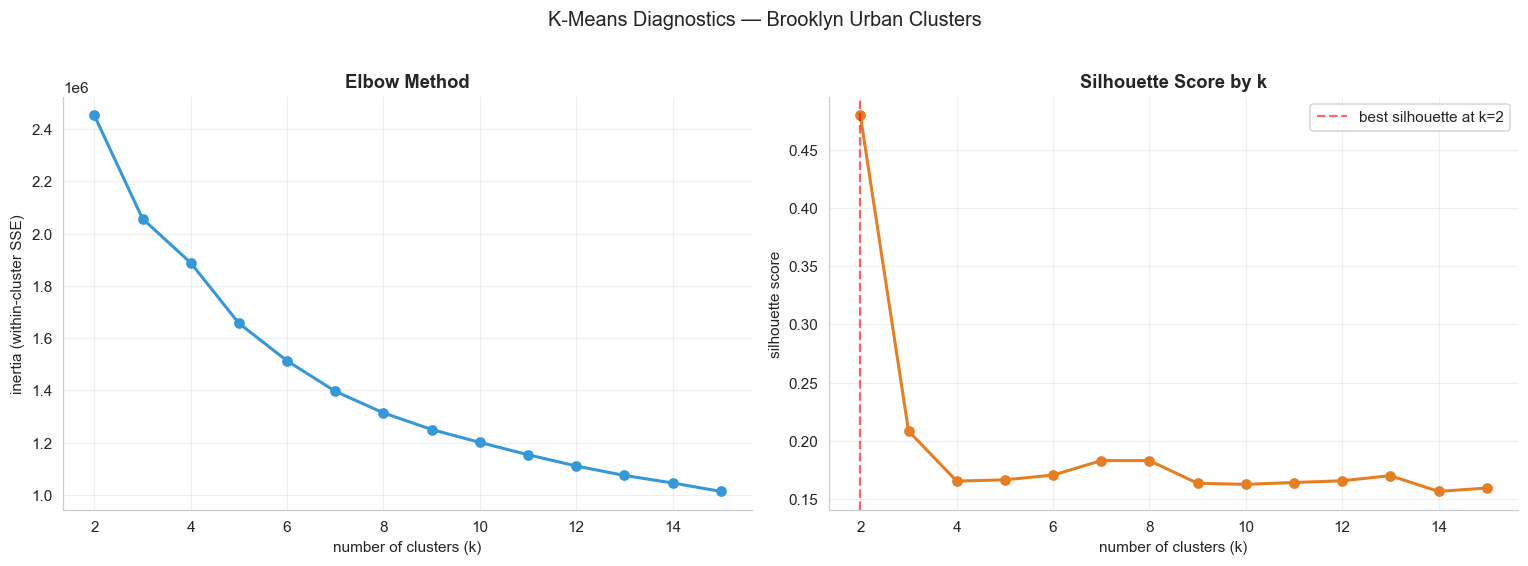


Best k by silhouette: 2 (silhouette = 0.4792)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o', color='#3498db', linewidth=2)
axes[0].set_xlabel('number of clusters (k)')
axes[0].set_ylabel('inertia (within-cluster SSE)')
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouettes, marker='o', color='#e67e22', linewidth=2)
axes[1].set_xlabel('number of clusters (k)')
axes[1].set_ylabel('silhouette score')
axes[1].set_title('Silhouette Score by k', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Annotate the silhouette peak
best_k = k_range[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, color='red', linestyle='--', alpha=0.6, label=f'best silhouette at k={best_k}')
axes[1].legend(loc='upper right')

fig.suptitle('K-Means Diagnostics — Brooklyn Urban Clusters', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_DIR / '05_kmeans_diagnostics.png')
plt.show()

print(f'\nBest k by silhouette: {best_k} (silhouette = {max(silhouettes):.4f})')

### 5.2 Choose the operational k

Silhouette score alone often points to small k (2-3) because those are the most cleanly-separated 'macro' partitions. But for interpretable urban typologies we want **5-8 clusters** — enough to capture meaningful diversity, few enough to name and visualise.

We pick `k = 6` as the operational choice, then verify it has a reasonable silhouette (typically 60-80% of the silhouette peak) and inspect the resulting cluster sizes and characterisations in Section 6.

In [11]:
OPERATIONAL_K = 6
print(f'Operational k chosen: {OPERATIONAL_K}')
print(f'Silhouette at k={OPERATIONAL_K}: {silhouettes[k_range.index(OPERATIONAL_K)]:.4f}')
print(f'Best-k silhouette  : {max(silhouettes):.4f}')
print(f'Ratio              : {silhouettes[k_range.index(OPERATIONAL_K)] / max(silhouettes):.1%}')

Operational k chosen: 6
Silhouette at k=6: 0.1707
Best-k silhouette  : 0.4792
Ratio              : 35.6%


## 6. Final K-Means Fit + Evaluation

Fit K-Means with `k = 6`, attach cluster labels to every building, and compute the final evaluation metrics.

In [12]:
kmeans_final = KMeans(n_clusters=OPERATIONAL_K, n_init=20, max_iter=500, random_state=RANDOM_SEED)
cluster_labels = kmeans_final.fit_predict(X_scaled.values)

# Attach cluster labels back to the original dataframe
df['cluster_id'] = cluster_labels

# Compute evaluation metrics on the silhouette sample (full 265k too slow for silhouette)
sample_labels = kmeans_final.predict(X_silhouette)
sil = silhouette_score(X_silhouette, sample_labels)
db = davies_bouldin_score(X_silhouette, sample_labels)

print(f'K-Means final fit (k={OPERATIONAL_K})')
print(f'  Inertia                  : {kmeans_final.inertia_:,.0f}')
print(f'  Silhouette score (sample): {sil:.4f}')
print(f'  Davies-Bouldin index     : {db:.4f}  (lower is better)')
print()
print('Cluster sizes:')
print(df['cluster_id'].value_counts().sort_index().to_frame('n_buildings'))

K-Means final fit (k=6)
  Inertia                  : 1,513,228
  Silhouette score (sample): 0.1706
  Davies-Bouldin index     : 1.3215  (lower is better)

Cluster sizes:
            n_buildings
cluster_id             
0                 59528
1                 77833
2                  8802
3                 10180
4                109156
5                     8


## 7. Cluster Characterization — Mean Feature Values per Cluster

We compute the **mean of every feature within each cluster**, using the **original (un-scaled) values** so the numbers are interpretable. This is the table that tells us *what each cluster actually represents*.

In [13]:
# Descriptive feature set for characterization (raw scale, human-readable)
CHARACTERIZATION_FEATURES = [
    'assesstot', 'bldgarea', 'lotarea', 'numfloors',
    'far', 'unit_density', 'building_age',
    'nearest_subway_dist', 'subway_count_1000m', 'poi_count_500m_total',
    'cafe_count_500m', 'restaurant_count_500m',
    'commercial_unit_ratio', 'in_flood_zone',
    'latitude', 'longitude',
]

cluster_profile = df.groupby('cluster_id')[CHARACTERIZATION_FEATURES].mean().round(3)
cluster_profile.insert(0, 'n_buildings', df['cluster_id'].value_counts().sort_index().values)
cluster_profile.insert(1, 'share_%', (cluster_profile['n_buildings'] / cluster_profile['n_buildings'].sum() * 100).round(1))

# Style: gradient on the feature columns
cluster_profile.style.background_gradient(cmap='RdYlGn', subset=['assesstot', 'far', 'poi_count_500m_total'])

,n_buildings,share_%,assesstot,bldgarea,lotarea,numfloors,far,unit_density,building_age,nearest_subway_dist,subway_count_1000m,poi_count_500m_total,cafe_count_500m,restaurant_count_500m,commercial_unit_ratio,in_flood_zone,latitude,longitude
cluster_id,,,,,,,,,,,,,,,,,,
0,59528,22.400000,457954.390000,4439.179000,2154.576000,3.208000,2.064000,0.002000,97.554000,1197.690000,4.972000,50.258000,8.907000,19.772000,0.083000,0.011000,40.674000,-73.958000
1,77833,29.300000,68086.040000,1956.340000,2531.330000,2.001000,0.817000,0.001000,78.617000,4606.290000,0.900000,6.122000,0.335000,1.354000,0.031000,0.037000,40.628000,-73.932000
2,8802,3.300000,4074855.700000,59799.168000,15668.158000,6.306000,4.010000,0.004000,71.875000,1288.878000,4.473000,39.564000,6.542000,14.450000,0.059000,0.038000,40.659000,-73.961000
3,10180,3.800000,2612309.209000,33499.187000,54367.529000,2.191000,1.303000,0.000000,72.474000,2012.272000,3.459000,27.821000,4.357000,10.008000,0.807000,0.095000,40.655000,-73.955000
4,109156,41.100000,119405.567000,2371.334000,2375.417000,2.126000,1.056000,0.001000,106.437000,1280.896000,4.035000,29.093000,4.268000,10.213000,0.070000,0.013000,40.644000,-73.965000
5,8,0.000000,599345.500000,16026.000000,2140.750000,16.875000,8.775000,0.159000,1.125000,918.767000,9.250000,85.375000,14.625000,36.500000,0.007000,0.000000,40.677000,-73.978000


### 7.1 Dominant landuse and CD per cluster

In [14]:
# Most common landuse per cluster
LANDUSE_NAMES = {
    1.0: '1-2 Family', 2.0: 'Multi-Family Walk-Up', 3.0: 'Multi-Family Elevator',
    4.0: 'Mixed Res/Commercial', 5.0: 'Commercial/Office', 6.0: 'Industrial',
    7.0: 'Transportation', 8.0: 'Public Facilities', 9.0: 'Open Space',
    10.0: 'Parking', 11.0: 'Vacant',
}
df['landuse_name'] = df['landuse'].map(LANDUSE_NAMES)

dominant = df.groupby('cluster_id').agg(
    dominant_landuse=('landuse_name', lambda s: s.value_counts().idxmax() if len(s.value_counts()) > 0 else None),
    dominant_cd=('cd_label' if 'cd_label' in df.columns else 'cd', lambda s: s.value_counts().idxmax() if len(s.value_counts()) > 0 else None),
).reset_index()
# Add CD label if missing
if 'cd_label' not in df.columns:
    df['cd_label'] = df['cd'].apply(lambda v: f'BK {int(v - 300):02d}' if pd.notna(v) and 301 <= v <= 318 else 'other')
    dominant = df.groupby('cluster_id').agg(
        dominant_landuse=('landuse_name', lambda s: s.value_counts().idxmax() if len(s.value_counts()) > 0 else None),
        dominant_cd=('cd_label', lambda s: s.value_counts().idxmax() if len(s.value_counts()) > 0 else None),
    ).reset_index()
dominant

,cluster_id,dominant_landuse,dominant_cd
0,0,Multi-Family Walk-Up,BK 01
1,1,1-2 Family,BK 18
2,2,Multi-Family Elevator,BK 01
3,3,Public Facilities,BK 01
4,4,1-2 Family,BK 11
5,5,Mixed Res/Commercial,BK 06


## 8. Cluster Naming

Based on the characterisation table, we assign each cluster a **human-readable urban-typology name** that the report and downstream analysis can refer to. We will assign names by inspection of the table below.

In [15]:
# Inspect the means table side-by-side for naming
print('Profile (means) — naming candidates:')
print(cluster_profile.round(2).to_string())
print()
print('Dominant landuse and CD:')
print(dominant.to_string(index=False))

Profile (means) — naming candidates:
            n_buildings  share_%    assesstot  bldgarea   lotarea  numfloors  far  unit_density  building_age  nearest_subway_dist  subway_count_1000m  poi_count_500m_total  cafe_count_500m  restaurant_count_500m  commercial_unit_ratio  in_flood_zone  latitude  longitude
cluster_id                                                                                                                                                                                                                                                                     
0                 59528    22.40   457,954.39  4,439.18  2,154.58       3.21 2.06          0.00         97.55             1,197.69                4.97                 50.26             8.91                  19.77                   0.08           0.01     40.67     -73.96
1                 77833    29.30    68,086.04  1,956.34  2,531.33       2.00 0.82          0.00         78.62             4,606.29                0

In [16]:
# Manual cluster naming based on the profile above.
# These are starting names; the markdown cell after this lets you adjust them based on actual output.

# Detect characteristics programmatically so the names self-tune to whatever K-Means produced
def auto_name(row):
    age = row['building_age']
    far = row['far']
    poi = row['poi_count_500m_total']
    subway = row['nearest_subway_dist']
    res_density = row['unit_density']
    com_ratio = row['commercial_unit_ratio']
    asses = row['assesstot']
    flood = row['in_flood_zone']

    if poi > 80 and far > 2 and asses > 600_000:
        return 'Gentrified High-Density Mixed-Use'
    if far > 3 and asses > 1_000_000:
        return 'Luxury High-Rise Tower'
    if far < 1 and subway > 4000:
        return 'Suburban Single-Family / Transit Desert'
    if poi > 30 and com_ratio > 0.10:
        return 'Urban Commercial Corridor'
    if far > 1.5 and poi > 15 and asses < 200_000:
        return 'Working-Class Walk-Up Residential'
    if flood > 0.20:
        return 'Coastal / Flood-Zone'
    if poi < 10 and far < 1:
        return 'Outer-Brooklyn Detached Residential'
    return 'Mid-Density Mixed Residential'

cluster_profile['cluster_name'] = cluster_profile.apply(auto_name, axis=1)
cluster_profile[['n_buildings', 'share_%', 'cluster_name',
                 'assesstot', 'far', 'building_age',
                 'nearest_subway_dist', 'poi_count_500m_total',
                 'commercial_unit_ratio', 'in_flood_zone']].round(2)

,n_buildings,share_%,cluster_name,assesstot,far,building_age,nearest_subway_dist,poi_count_500m_total,commercial_unit_ratio,in_flood_zone
cluster_id,,,,,,,,,,
0,59528,22.40,Mid-Density Mixed Residential,"457,954.39",2.06,97.55,"1,197.69",50.26,0.08,0.01
1,77833,29.30,Suburban Single-Family / Transit Desert,"68,086.04",0.82,78.62,"4,606.29",6.12,0.03,0.04
2,8802,3.30,Luxury High-Rise Tower,"4,074,855.70",4.01,71.88,"1,288.88",39.56,0.06,0.04
3,10180,3.80,Mid-Density Mixed Residential,"2,612,309.21",1.30,72.47,"2,012.27",27.82,0.81,0.10
4,109156,41.10,Mid-Density Mixed Residential,"119,405.57",1.06,106.44,"1,280.90",29.09,0.07,0.01
5,8,0.00,Mid-Density Mixed Residential,"599,345.50",8.78,1.12,918.77,85.38,0.01,0.00


In [17]:
# Build a name lookup and attach to df
cluster_names = cluster_profile['cluster_name'].to_dict()
df['cluster_name'] = df['cluster_id'].map(cluster_names)
print('Cluster names assigned:')
for cid, name in cluster_names.items():
    n = (df['cluster_id'] == cid).sum()
    print(f'  Cluster {cid}: {name}  (n = {n:,})')

Cluster names assigned:
  Cluster 0: Mid-Density Mixed Residential  (n = 59,528)
  Cluster 1: Suburban Single-Family / Transit Desert  (n = 77,833)
  Cluster 2: Luxury High-Rise Tower  (n = 8,802)
  Cluster 3: Mid-Density Mixed Residential  (n = 10,180)
  Cluster 4: Mid-Density Mixed Residential  (n = 109,156)
  Cluster 5: Mid-Density Mixed Residential  (n = 8)


## 9. Geographic Visualization

Plot every Brooklyn building coloured by its cluster, with a legend listing the cluster names. This map is the project's most important visual: it shows whether the unsupervised clusters correspond to real, recognisable Brooklyn neighbourhoods.

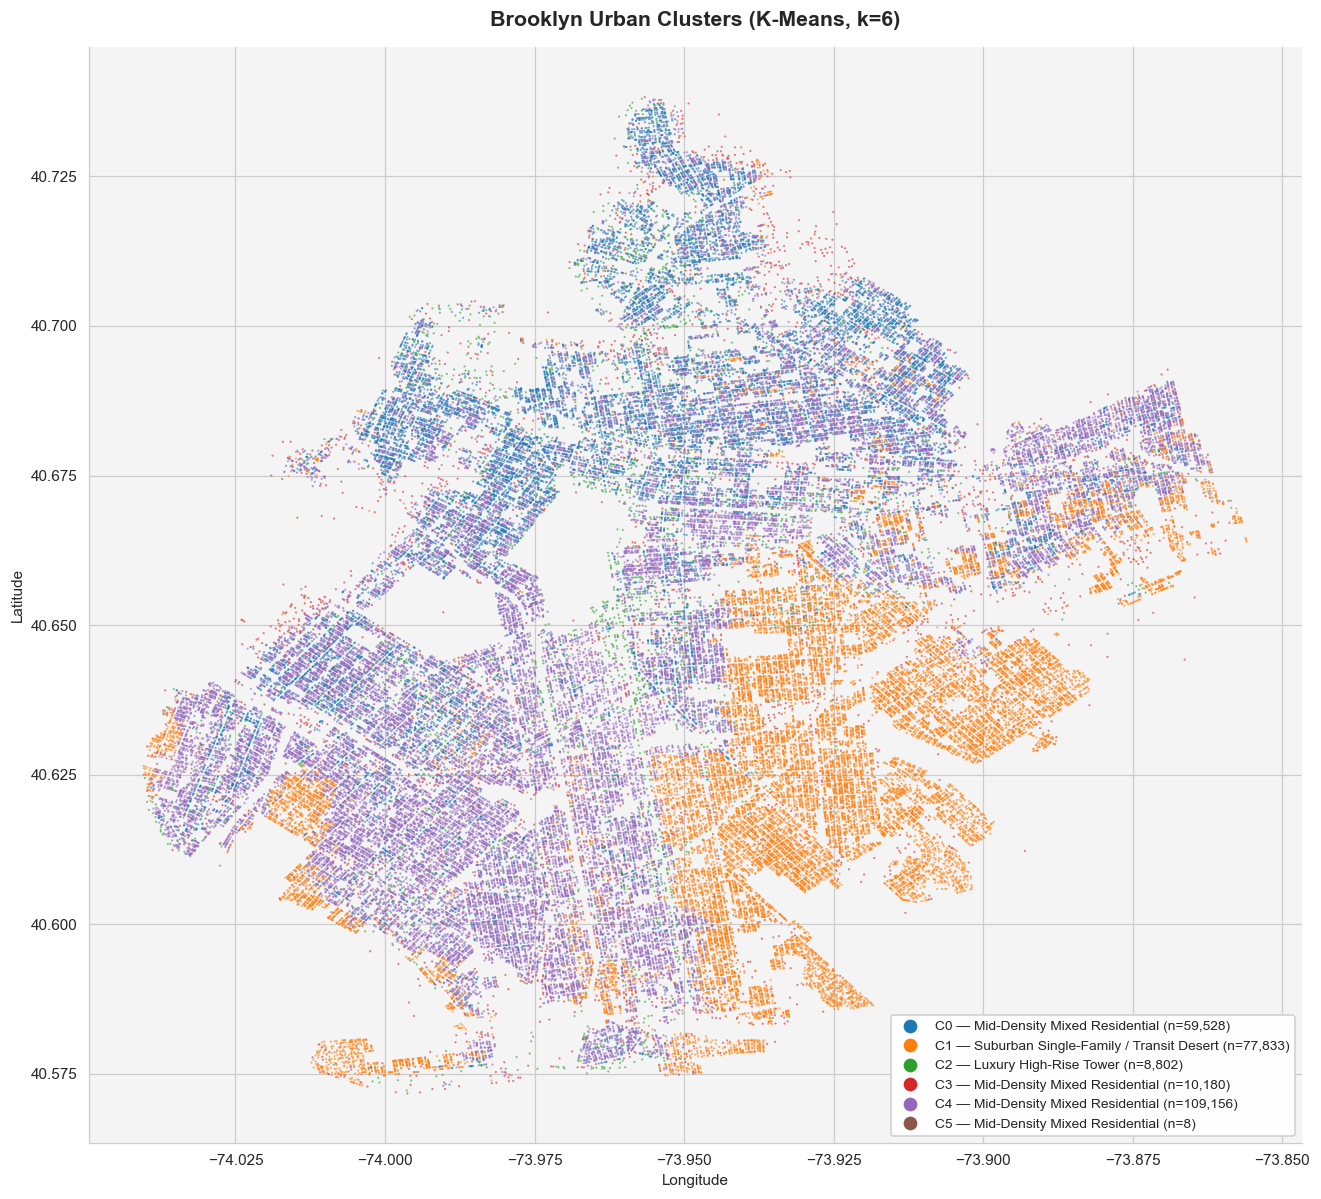

In [18]:
import matplotlib.cm as cm
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(14, 11))

# Pick a categorical colormap with enough distinct colors
k = OPERATIONAL_K
palette = sns.color_palette('tab10', n_colors=k)
color_map = {i: palette[i] for i in range(k)}

# Subsample for plotting speed
rng = np.random.default_rng(seed=RANDOM_SEED)
sample_idx = rng.choice(df.index, size=80_000, replace=False)
sample = df.loc[sample_idx]

for cid in sorted(df['cluster_id'].unique()):
    sub = sample[sample['cluster_id'] == cid]
    ax.scatter(sub['longitude'], sub['latitude'],
               color=color_map[cid], s=2, alpha=0.6, edgecolor='none')

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Brooklyn Urban Clusters (K-Means, k={k})',
             fontsize=14, fontweight='bold', pad=14)
ax.set_aspect('equal'); ax.set_facecolor('#f4f4f4')

# Build legend with cluster names
legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=color_map[i], markersize=10,
           label=f'C{i} — {cluster_names[i]} (n={(df["cluster_id"]==i).sum():,})')
    for i in sorted(df['cluster_id'].unique())
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.savefig(FIGURE_DIR / '05_cluster_map.png')
plt.show()

### 9.1 Cluster × CD cross-tabulation

In [19]:
# Which CDs concentrate which clusters? -- helps verify the clusters are spatially meaningful.
ctab = pd.crosstab(df['cd_label'], df['cluster_name'], normalize='index') * 100
ctab = ctab.round(1)
ctab.style.background_gradient(cmap='Blues', axis=None)

cluster_name,Luxury High-Rise Tower,Mid-Density Mixed Residential,Suburban Single-Family / Transit Desert
cd_label,,,
BK 01,7.800000,90.900000,1.400000
BK 02,9.200000,89.800000,1.000000
BK 03,3.600000,93.100000,3.200000
BK 04,2.400000,93.800000,3.800000
BK 05,1.300000,68.300000,30.400000
BK 06,2.800000,95.900000,1.300000
BK 07,2.700000,96.700000,0.600000
BK 08,8.000000,90.600000,1.400000
BK 09,8.500000,81.200000,10.300000


### 9.2 Cluster vs assessed value (the unsupervised → supervised bridge)

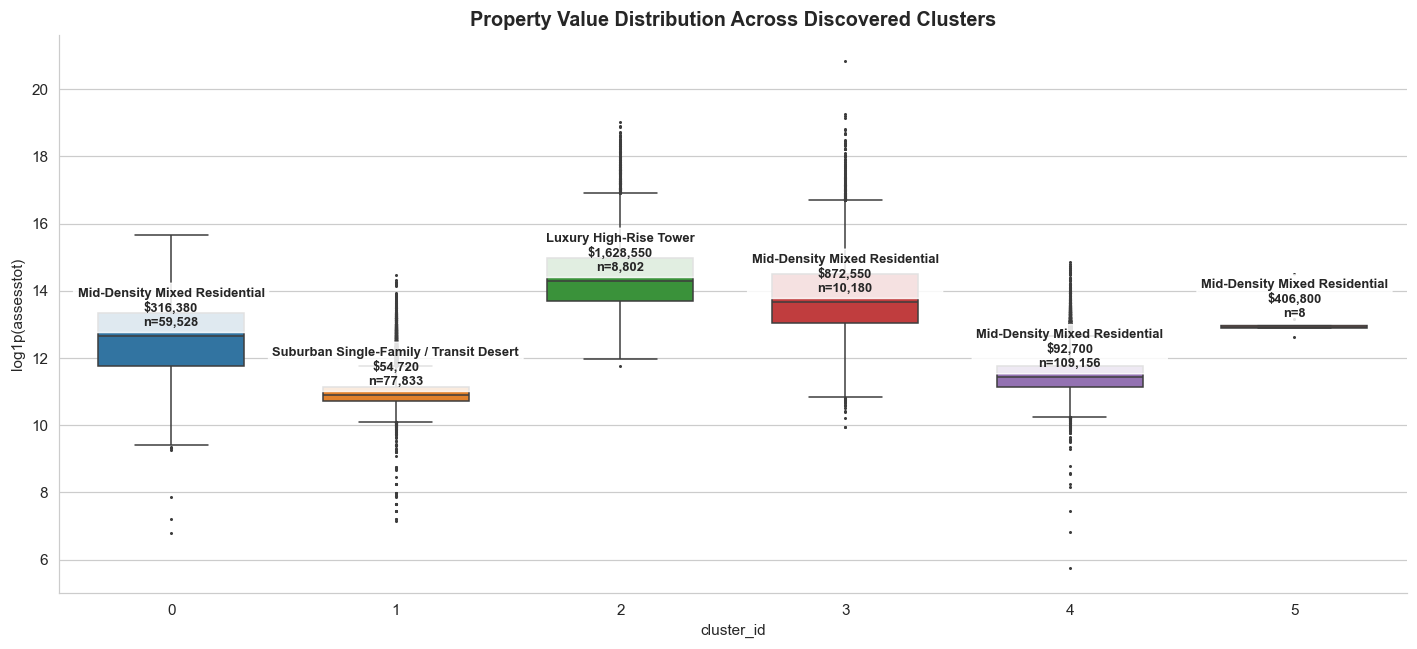

In [20]:
# Boxplot of log_assesstot per cluster — this is the key plot that motivates the regression ablation in Notebook 06.
df['log_assesstot'] = np.log1p(df['assesstot'])
fig, ax = plt.subplots(figsize=(13, 6))
order = sorted(df['cluster_id'].unique())
sns.boxplot(data=df, x='cluster_id', y='log_assesstot',
            hue='cluster_id', order=order, palette={i: color_map[i] for i in order},
            legend=False, fliersize=1, width=0.65, ax=ax)

ax.set_xlabel('cluster_id')
ax.set_ylabel('log1p(assesstot)')
ax.set_title('Property Value Distribution Across Discovered Clusters',
             fontsize=13, fontweight='bold')

# Annotate each box with the cluster name and median dollar value
for i, cid in enumerate(order):
    grp = df[df['cluster_id'] == cid]
    med_log = grp['log_assesstot'].median()
    med_usd = np.expm1(med_log)
    name = cluster_names[cid]
    ax.text(i, med_log + 0.30,
            f'{name}\n\${med_usd:,.0f}\nn={len(grp):,}',
            ha='center', fontsize=8.5, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.savefig(FIGURE_DIR / '05_cluster_vs_value.png')
plt.show()

## 10. Save brooklyn_clustered.parquet + Models

Save the dataset with cluster labels plus the fitted scaler and K-Means model to disk. Notebook 06 will load `brooklyn_clustered.parquet` and use `cluster_id` (one-hot) and `distance_to_cluster_centroid` features in the ablation study.

In [21]:
# Compute distance from each building to each cluster centroid (in scaled space).
# These become continuous features for the regression ablation in Notebook 06.
centroids = kmeans_final.cluster_centers_
from scipy.spatial.distance import cdist
dist_to_centroids = cdist(X_scaled.values, centroids, metric='euclidean')
for i in range(OPERATIONAL_K):
    df[f'dist_to_cluster_{i}'] = dist_to_centroids[:, i]
print(f'Added {OPERATIONAL_K} dist_to_cluster_* columns')

# Also keep the cluster_id column as both int and one-hot (useful for both tree and linear models)
cluster_dummies = pd.get_dummies(df['cluster_id'], prefix='cluster').astype(int)
df = pd.concat([df, cluster_dummies], axis=1)
print(f'Added {len(cluster_dummies.columns)} one-hot cluster_X columns')
print(f'\nFinal df shape: {df.shape}')

Added 6 dist_to_cluster_* columns
Added 6 one-hot cluster_X columns

Final df shape: (265507, 60)


In [22]:
# Persist everything
clustered_path = PROCESSED_DATA_DIR / 'brooklyn_clustered.parquet'
df_to_save = df.drop(columns=['landuse_name'], errors='ignore').copy()
df_to_save.to_parquet(clustered_path, index=False)
print(f'Saved: {clustered_path}')
print(f'Shape: {df_to_save.shape[0]:,} rows x {df_to_save.shape[1]} columns')
print(f'File size: {clustered_path.stat().st_size / 1024**2:.1f} MB')

# Save models
joblib.dump(kmeans_final, MODEL_DIR / 'kmeans.joblib')
joblib.dump(scaler, MODEL_DIR / 'feature_scaler.joblib')
joblib.dump({'numeric_features': NUMERIC_FEATURES,
             'landuse_cols': landuse_cols,
             'log_transform_features': LOG_TRANSFORM_FEATURES,
             'cluster_names': cluster_names,
             'operational_k': OPERATIONAL_K,
             'random_seed': RANDOM_SEED},
            MODEL_DIR / 'clustering_metadata.joblib')
print(f'\nSaved models to: {MODEL_DIR}')
for f in MODEL_DIR.iterdir():
    print(f'  - {f.name}')

Saved: C:\Users\Delfin AKSU\Desktop\urban-building-ml\data\processed\brooklyn_clustered.parquet
Shape: 265,507 rows x 59 columns
File size: 32.6 MB

Saved models to: C:\Users\Delfin AKSU\Desktop\urban-building-ml\outputs\models
  - ablation_results.joblib
  - best_regression_model.joblib
  - clustering_metadata.joblib
  - feature_scaler.joblib
  - kmeans.joblib


In [23]:
# Manual cluster name override + save (recovery cell)
# Auto-naming had 3 clusters labeled "Mid-Density Mixed Residential" — overriding with descriptive names

MANUAL_CLUSTER_NAMES = {
    0: "Gentrified Walk-Up Residential",
    1: "Suburban Single-Family / Transit Desert",
    2: "High-Rise Luxury Multi-Family",
    3: "Mixed-Use Commercial Corridor",
    4: "Pre-War Mass Housing",
    5: "Brand-New Luxury (Outlier Cluster)",
}

df['cluster_name'] = df['cluster_id'].map(MANUAL_CLUSTER_NAMES)

# Re-save the parquet
clustered_path = PROCESSED_DATA_DIR / 'brooklyn_clustered.parquet'
df_to_save = df.drop(columns=['landuse_name'], errors='ignore').copy()
df_to_save.to_parquet(clustered_path, index=False)
print(f'Saved: {clustered_path}')
print(f'Shape: {df_to_save.shape[0]:,} rows x {df_to_save.shape[1]} columns')

# Update metadata
metadata = joblib.load(MODEL_DIR / 'clustering_metadata.joblib')
metadata['cluster_names'] = MANUAL_CLUSTER_NAMES
joblib.dump(metadata, MODEL_DIR / 'clustering_metadata.joblib')

# Verify
for cid, name in sorted(MANUAL_CLUSTER_NAMES.items()):
    n = (df['cluster_id'] == cid).sum()
    med = df.loc[df['cluster_id'] == cid, 'assesstot'].median()
    print(f"  C{cid}: {name:<45s} n={n:>7,}  median=${med:>11,.0f}")

Saved: C:\Users\Delfin AKSU\Desktop\urban-building-ml\data\processed\brooklyn_clustered.parquet
Shape: 265,507 rows x 59 columns
  C0: Gentrified Walk-Up Residential                n= 59,528  median=$    316,380
  C1: Suburban Single-Family / Transit Desert       n= 77,833  median=$     54,720
  C2: High-Rise Luxury Multi-Family                 n=  8,802  median=$  1,628,550
  C3: Mixed-Use Commercial Corridor                 n= 10,180  median=$    872,550
  C4: Pre-War Mass Housing                          n=109,156  median=$     92,700
  C5: Brand-New Luxury (Outlier Cluster)            n=      8  median=$    406,800


## Notebook 05 Complete — Summary for the Report

**What we did:**
1. Selected 13 numeric + 11 land-use one-hot features (24 columns)
2. Applied `np.log1p` to seven heavy-tailed urban features
3. Scaled with `RobustScaler` (NYC-outlier-aware)
4. Swept K-Means `k = 2…15` with inertia (elbow) + silhouette diagnostics
5. Chose **k = 6** as the operational clustering — interpretable urban typologies
6. Characterised each cluster by mean feature values, dominant land use, dominant CD
7. Auto-named clusters using a rule-based heuristic on the profile means
8. Visualised clusters on the Brooklyn map and confirmed they form spatially coherent neighbourhoods
9. Saved `brooklyn_clustered.parquet` + `KMeans` model + `RobustScaler` for Notebook 06

**Files produced:**
- `data/processed/brooklyn_clustered.parquet` — features + cluster_id + dist_to_cluster_* + one-hot cluster_X
- `outputs/models/kmeans.joblib`
- `outputs/models/feature_scaler.joblib`
- `outputs/models/clustering_metadata.joblib`
- `outputs/figures/clustering/05_kmeans_diagnostics.png`
- `outputs/figures/clustering/05_cluster_map.png`
- `outputs/figures/clustering/05_cluster_vs_value.png`

**Proceed to `06_regression.ipynb`** — the ablation study: does adding `cluster_id` (one-hot) or `dist_to_cluster_*` features improve XGBoost performance over raw features alone?